In [30]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
sns.set_style("white")
from matplotlib.image import imread

In [31]:
work_dir = os.getcwd()
work_dir

'/workspaces/XrayFractureClass/jupytr_notebooks'

In [32]:
my_data_dir = '../data/test/'
train_path = my_data_dir + '/train'
val_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'

In [33]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(work_dir) and version in os.listdir(work_dir + '/outputs'):
    print('Old version is already available create a new version.')
    pass
else:
    os.makedirs(name=file_path)

Old version is already available create a new version.


In [34]:
labels = os.listdir(train_path)
print('Label for the images are', labels)

Label for the images are ['normal', 'fracture']


In [35]:
ls /workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/

test/  train/  val/


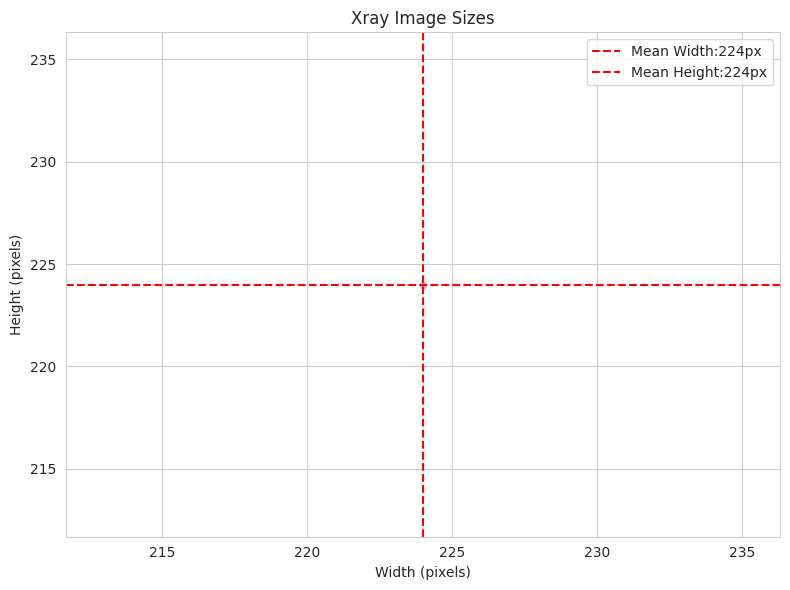

Width average: 224 
Height average: 224


In [36]:
train_path ='/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train'
labels = os.listdir(train_path)

VALID_EXTENTIONS = ('.jpg', '.jpeg','.png','.bmp','.tiff','.tif')
dim1, dim2 = [], []

for label in labels:
    label_path = os.path.join(train_path, label)
    if not os.path.isdir(label_path):
        continue
    for image_filename in os.listdir(label_path):
        if not image_filename.lower().endswith(VALID_EXTENTIONS):
            continue
    img_path = os.path.join(label_path, image_filename)
    try:
        img = imread(img_path)
    except Exception as e:
        print (f"Skiping this image {image_filename}: {e}")
        continue
    if img.ndim == 2:
            d1, d2 = img.shape
    elif img.ndim ==3:
            d1, d2, _ = img.shape
    else:
         continue
    dim1.append(d1)
    dim2.append(d2)
    
dim1_mean = int(np.array(dim1).mean())
dim2_mean = int(np.array(dim2).mean()) 

sns.set_style("whitegrid")
fig, axes = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=dim2, y=dim1, alpha=0.2, ax=axes)
axes.set_xlabel("Width (pixels)")
axes.set_ylabel("Height (pixels)")
axes.set_title("Xray Image Sizes")
axes.axhline(y=dim2_mean, color='r', linestyle='--', label=f"Mean Width:{dim2_mean}px")
axes.axvline(x=dim1_mean, color='r', linestyle='--', label = f"Mean Height:{dim1_mean}px")
axes.legend()
plt.tight_layout()
plt.show()

print(f"Width average: {dim2_mean} \nHeight average: {dim1_mean}")


In [37]:
image_shape = (dim1_mean, dim2_mean, 3)
image_shape

(224, 224, 3)

In [38]:
joblib.dump(value=image_shape ,
            filename=f"{file_path}/image_shape.pkl")

['outputs/v1/image_shape.pkl']

In [39]:
from tensorflow.keras.preprocessing import image


def load_image_as_array(my_data_dir, new_size=(50, 50), n_images_per_label=20):

    X, y = np.array([], dtype='int'), np.array([], dtype='object')
    labels = os.listdir(my_data_dir)

    for label in labels:
        counter = 0
        for image_filename in os.listdir(my_data_dir + '/' + label):
            # n_images_per_label: we set a limit, since it may take too much time
            if counter < n_images_per_label:

                img = image.load_img(
                    my_data_dir + '/' + label + '/' + image_filename, target_size=new_size)
                if image.img_to_array(img).max() > 1:
                    img_resized = image.img_to_array(img) / 255
                else:
                    img_resized = image.img_to_array(img)

                X = np.append(X, img_resized).reshape(-1,
                                                      new_size[0], new_size[1], img_resized.shape[2])
                y = np.append(y, label)
                counter += 1

    return X, y

I0000 00:00:1779475672.555055   49340 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779475672.644627   49340 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779475687.587337   49340 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779475696.930250   49340 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.